# Phase A — Preprocessing & Corrections

**Dataset:** WARD00034-R2, D28 AB Rep1 (`5c6bf125`)
**Zarr store:** `WARD00034_R2.zarr`  |  field shape `[T=1, C=4, Z=10, Y=2160, X=2160]` uint16
**Pixel size:** 0.2967 µm/px, Z-spacing: 1.997 µm

Covers: zarr store structure · raw channel overview · vignetting · MIP vs best-focus · calibration.

In [1]:
%matplotlib inline
from pathlib import Path
import zarr, numpy as np, tifffile
import matplotlib.pyplot as plt, matplotlib.colors as mc
from matplotlib.colors import LinearSegmentedColormap
from skimage.filters import laplace

REPO    = Path('/Users/pmihack/claire/hs-array')
ZARR    = REPO / 'data/WARD00034_R2.zarr'
FIGDIR  = Path(__file__).parent / 'figures/phase_A' if '__file__' in dir() else Path(
    '/Users/pmihack/claire/hs-array/resources/iNDI_microscopy_production/notebooks/figures/phase_A')
FIGDIR.mkdir(parents=True, exist_ok=True)

PX_UM = 0.2967; Z_UM = 1.997; DPI = 300; BG = 'black'; FG = 'white'

def _p(img, lo=0.5, hi=99.5):
    v = img.astype(np.float32)
    return np.percentile(v, lo), np.percentile(v, hi)

store = zarr.open(str(ZARR), mode='r')
print(f"Zarr store opened: {ZARR.name}")
print(f"Top-level keys (row letters): {sorted(store.keys())}")

Zarr store opened: WARD00034_R2.zarr
Top-level keys (row letters): ['C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N']


## Step 1 — Zarr Store Structure

In [2]:
# Plate metadata from zarr.json
attrs = dict(store.attrs)
ome   = attrs['ome']
plate = ome['plate']

print(f"Plate name:  {attrs['experiment_metadata']['plate_name']}")
print(f"Rows:        {[r['name'] for r in plate['rows']]}")
print(f"Columns:     {[c['name'] for c in plate['columns']]}")
print(f"Wells:       {len(plate['wells'])} total")
print(f"Acquisitions:{plate.get('acquisitions', [])}")
print()

# Channel metadata
print("Channel metadata (from zarr.json channels_metadata):")
for ch in attrs['channels_metadata']:
    print(f"  ch{ch['channel_id']}: {ch['name']:10s}  ex={ch['excitation_nm']}nm  em={ch['emission_nm']}nm")
print()

# One field shape
arr = store['C']['7']['4']['0']
print(f"Field C/7/f4 array shape: {arr.shape}  dtype: {arr.dtype}")
print("Axes: [T, C, Z, Y, X] = [1, 4, 10, 2160, 2160]")
print()

# Flatfield profiles
fp = attrs['flatfield_profiles']
print(f"flatfield_profiles: {len(fp)} channel profiles (present in zarr.json, NOT applied at load time)")
for p in fp:
    ptype = type(p['profile']).__name__
    print(f"  channel_id={p['channel_id']}  profile type={ptype}")
print("→ Flatfield profiles are stored as metadata; correction is applied in analysis scripts, not pre-baked into pixel data.")

Plate name:  WARD00034
Rows:        ['C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N']
Columns:     ['3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18']
Wells:       192 total
Acquisitions:[{'id': 0}]

Channel metadata (from zarr.json channels_metadata):
  ch1: DAPI        ex=375nm  em=456nm
  ch2: Alexa 488   ex=488nm  em=522nm
  ch3: CF568       ex=561nm  em=599nm
  ch4: Alexa 647   ex=640nm  em=706nm

Field C/7/f4 array shape: (1, 4, 10, 2160, 2160)  dtype: uint16
Axes: [T, C, Z, Y, X] = [1, 4, 10, 2160, 2160]

flatfield_profiles: 4 channel profiles (present in zarr.json, NOT applied at load time)
  channel_id=1  profile type=str
  channel_id=2  profile type=str
  channel_id=3  profile type=str
  channel_id=4  profile type=str
→ Flatfield profiles are stored as metadata; correction is applied in analysis scripts, not pre-baked into pixel data.


## Step 2 — Raw Channel Overview

All 4 channels, z=5 (mid-stack), field C/7/f4.

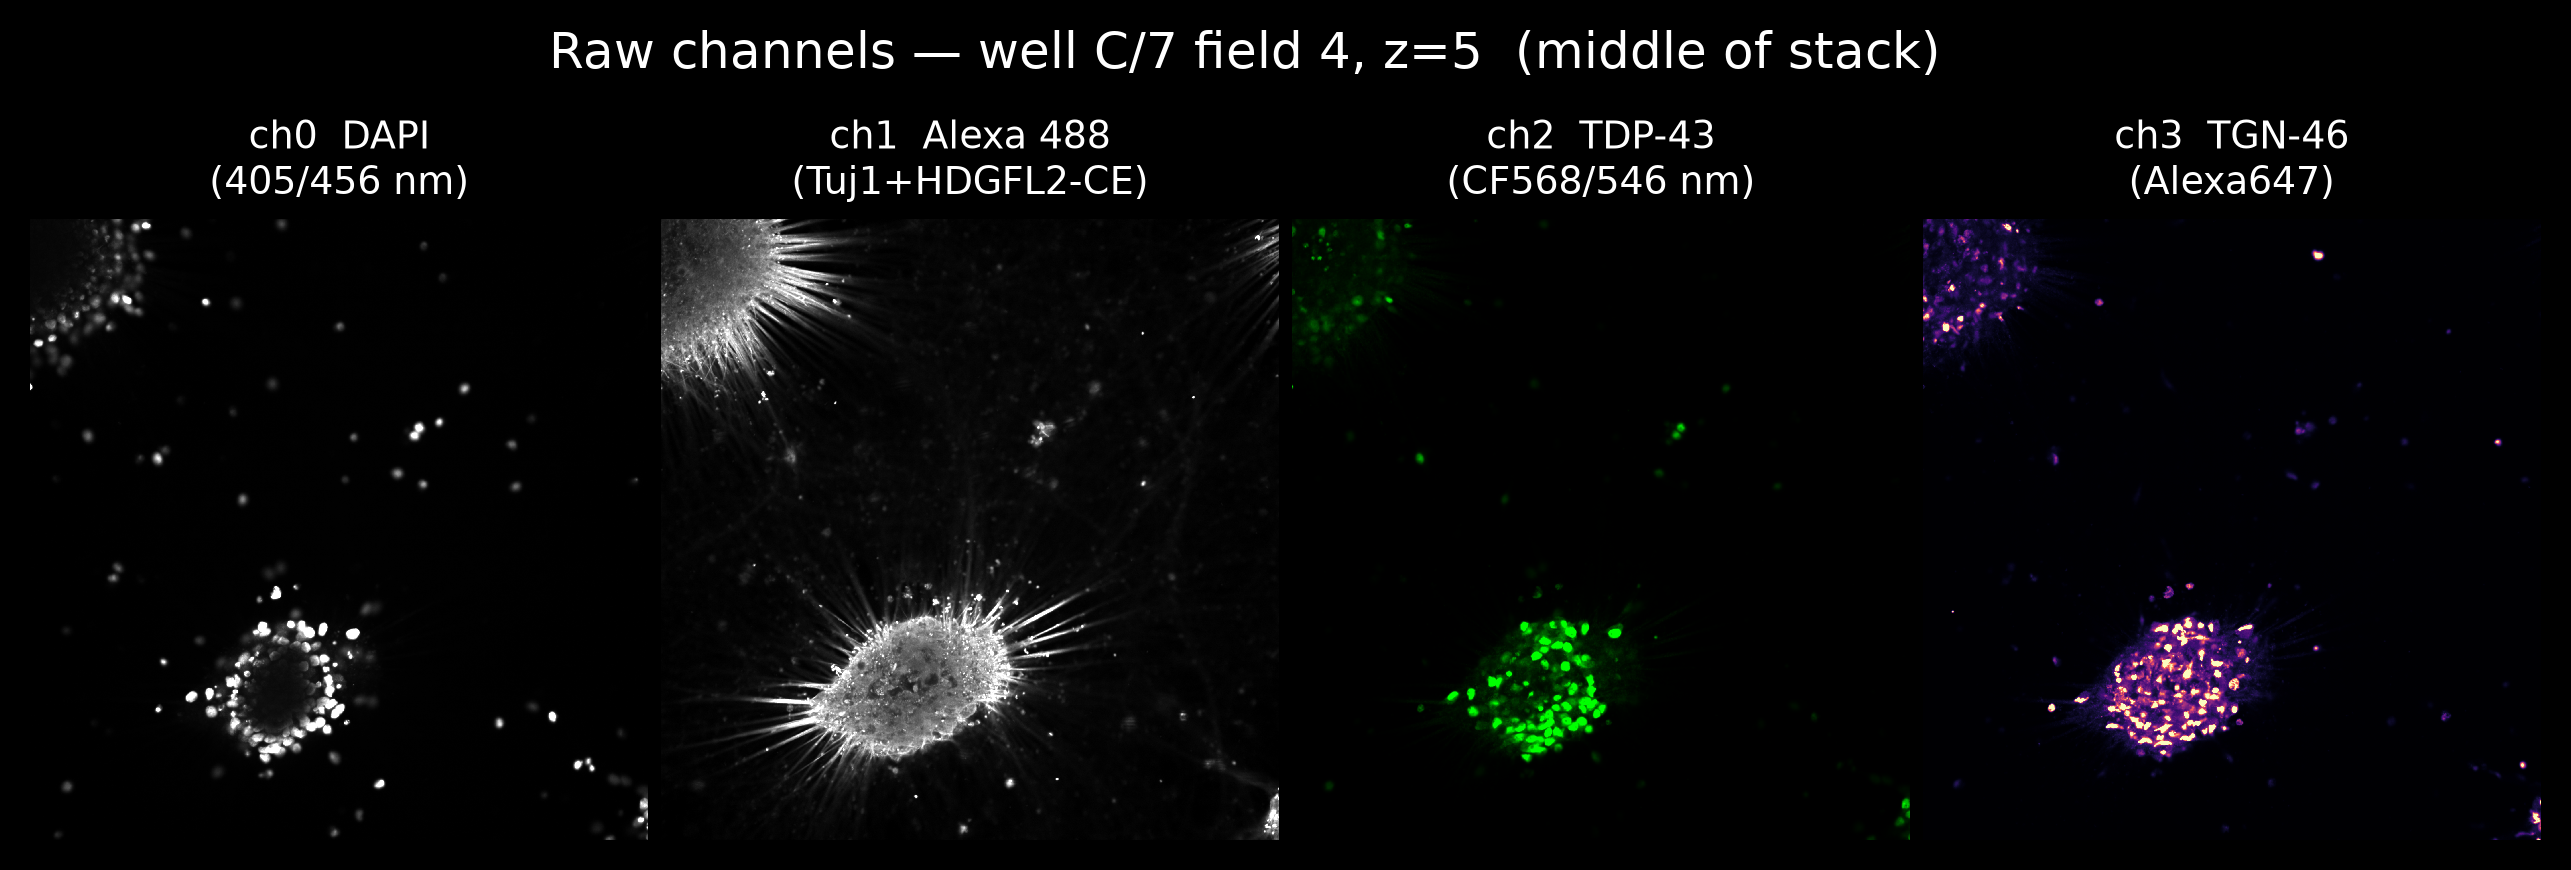

Saved: 01_raw_channels.png


In [3]:
# shape: (1, 4, 10, 2160, 2160)  →  slice [T=0, all_C, Z=5, :, :]
data = arr[0, :, 5, :, :]  # (4, 2160, 2160) uint16

CH_NAMES  = ['DAPI\n(405/456 nm)', 'Alexa 488\n(Tuj1+HDGFL2-CE)', 'TDP-43\n(CF568/546 nm)', 'TGN-46\n(Alexa647)']
K2G       = LinearSegmentedColormap.from_list('k2g', ['black', 'lime'])

fig, axs = plt.subplots(1, 4, figsize=(10.8, 3.0), facecolor=BG, dpi=DPI)
fig.suptitle('Raw channels — well C/7 field 4, z=5  (middle of stack)', color=FG, y=1.01)
plt.subplots_adjust(hspace=0.02, wspace=0.02, top=0.80)

cmaps = ['gray', 'gray', K2G, 'magma']
for i, (ax, name, cmap) in enumerate(zip(axs, CH_NAMES, cmaps)):
    plane = data[i].astype(np.float32)
    vmin, vmax = _p(plane)
    ax.imshow(plane, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
    ax.set_title(f'ch{i}  {name}', color=FG, fontsize=9)
    ax.set_facecolor(BG); ax.axis('off')
    for s in ax.spines.values(): s.set_color(FG)

fig.savefig(FIGDIR / '01_raw_channels.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: 01_raw_channels.png")

## Step 3 — Vignetting Demonstration

Why flatfield correction matters: intensity falls off toward the image corners due to
uneven illumination (vignetting). This biases per-cell measurements in edge-of-field positions.

Load all 9 fields of well C/7 and compute mean intensity per field per channel.
Then compute corner-vs-center ratio on the DAPI channel.

Fields in well C/7: ['0', '1', '2', '3', '4', '5', '6', '7', '8']


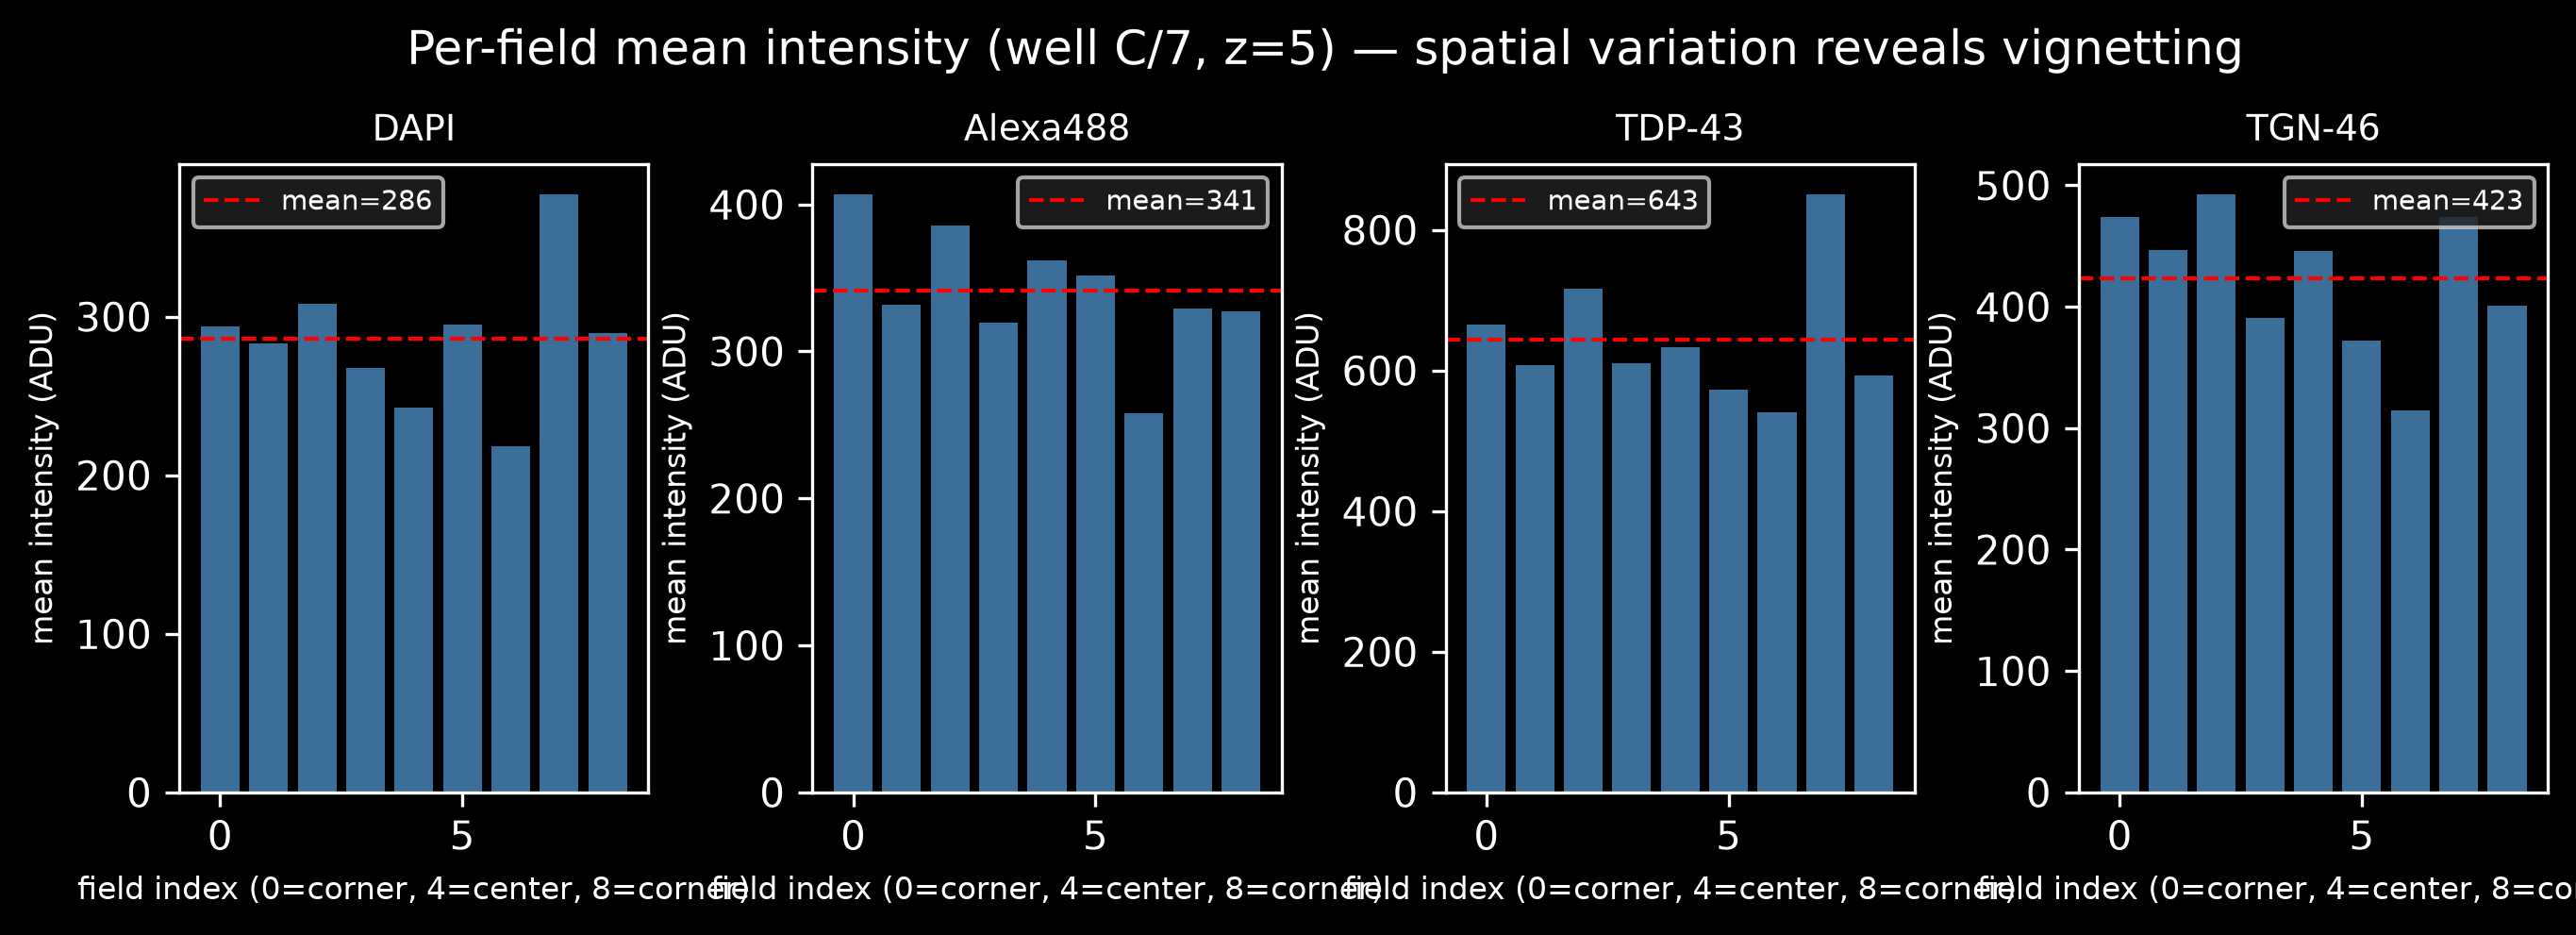

Corner mean (4 × 256² patches):  246.9 ADU
Center mean (256² central patch): 130.0 ADU
Corner/Center ratio: 1.899  →  no obvious vignetting


/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_31413/2209642809.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs2[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=7)


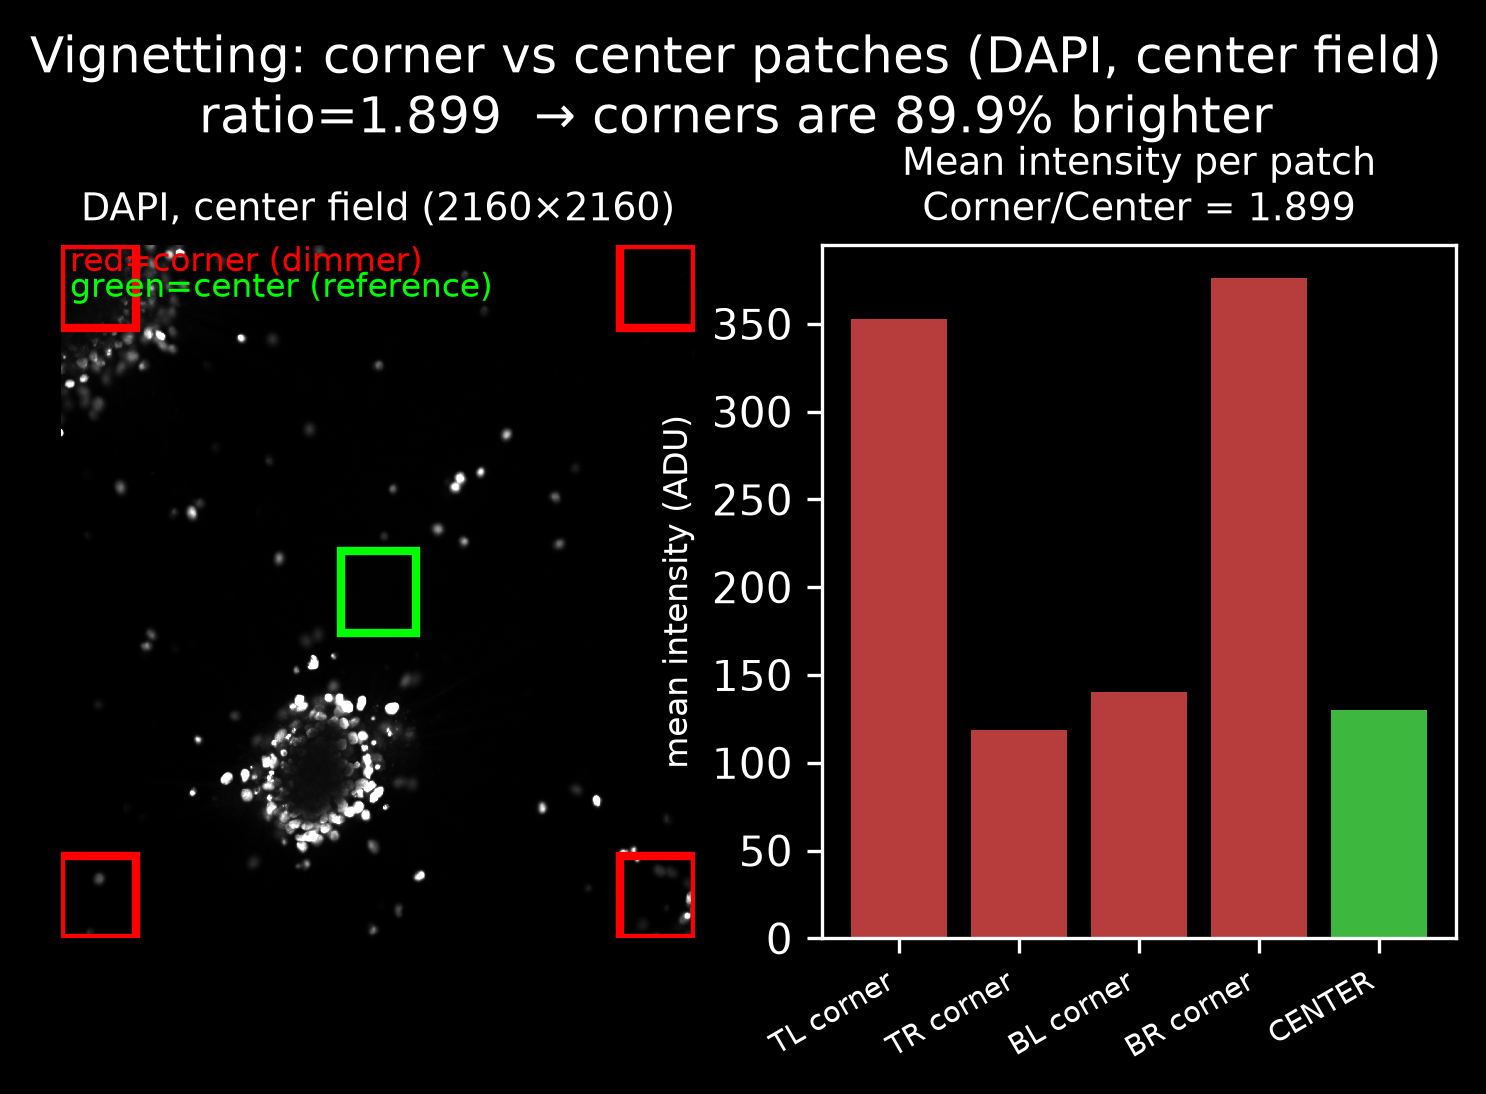

Saved: 03_vignetting_corner_center.png


In [4]:
well = store['C']['7']
field_keys = sorted(well.keys())  # 0–8
print(f"Fields in well C/7: {field_keys}")

# Per-field mean intensity for each channel (one z-plane per field)
Z_DEMO = 5
field_means = np.zeros((len(field_keys), 4))
for fi, fk in enumerate(field_keys):
    plane4 = well[fk]['0'][0, :, Z_DEMO, :, :]  # (4, 2160, 2160)
    for ch in range(4):
        field_means[fi, ch] = plane4[ch].mean()

ch_labels = ['DAPI', 'Alexa488', 'TDP-43', 'TGN-46']
fig, axs = plt.subplots(1, 4, figsize=(10.8, 3.0), facecolor=BG, dpi=DPI)
fig.suptitle('Per-field mean intensity (well C/7, z=5) — spatial variation reveals vignetting',
             color=FG, y=1.01)
plt.subplots_adjust(wspace=0.35, top=0.85)

for ch in range(4):
    ax = axs[ch]
    vals = field_means[:, ch]
    ax.bar(range(len(field_keys)), vals, color='steelblue', alpha=0.85, edgecolor='none')
    ax.set_facecolor(BG); ax.tick_params(colors=FG); ax.title.set_color(FG)
    for s in ax.spines.values(): s.set_color(FG)
    ax.set_xlabel('field index (0=corner, 4=center, 8=corner)', color=FG, fontsize=8)
    ax.set_ylabel('mean intensity (ADU)', color=FG, fontsize=8)
    ax.set_title(ch_labels[ch], color=FG, fontsize=9)
    ax.axhline(vals.mean(), color='red', ls='--', lw=1, label=f'mean={vals.mean():.0f}')
    ax.legend(fontsize=7, labelcolor='white', facecolor='#222')

fig.savefig(FIGDIR / '02_per_field_mean_intensity.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()

# Corner vs center ratio (DAPI channel, center field = index 4)
center_img = well['4']['0'][0, 0, Z_DEMO, :, :]  # (2160, 2160)
H, W = center_img.shape
P = 256
corners = [center_img[:P, :P], center_img[:P, W-P:],
           center_img[H-P:, :P], center_img[H-P:, W-P:]]
corner_mean = np.mean([c.mean() for c in corners])
center_mean  = center_img[H//2-P//2:H//2+P//2, W//2-P//2:W//2+P//2].mean()
ratio = corner_mean / center_mean

print(f"Corner mean (4 × 256² patches):  {corner_mean:.1f} ADU")
print(f"Center mean (256² central patch): {center_mean:.1f} ADU")
print(f"Corner/Center ratio: {ratio:.3f}  →  {'vignetting present (corners dimmer)' if ratio < 1 else 'no obvious vignetting'}")

# Show the patches
fig2, axs2 = plt.subplots(1, 2, figsize=(6.0, 3.0), facecolor=BG, dpi=DPI)
fig2.suptitle(f'Vignetting: corner vs center patches (DAPI, center field)\n'
              f'ratio={ratio:.3f}  → corners are {abs(1-ratio)*100:.1f}% {"dimmer" if ratio<1 else "brighter"}',
              color=FG, y=1.12)
for ax in axs2:
    ax.set_facecolor(BG); ax.tick_params(colors=FG)
    for s in ax.spines.values(): s.set_color(FG)

vmin, vmax = _p(center_img)
axs2[0].imshow(center_img, cmap='gray', vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
axs2[0].set_title('DAPI, center field (2160×2160)', color=FG, fontsize=9)
# overlay corner rectangles
import matplotlib.patches as mpatches
for (y0r, x0r) in [(0,0),(0,W-P),(H-P,0),(H-P,W-P)]:
    axs2[0].add_patch(mpatches.Rectangle((x0r,y0r), P, P, lw=2, edgecolor='red', facecolor='none'))
axs2[0].add_patch(mpatches.Rectangle((W//2-P//2, H//2-P//2), P, P, lw=2, edgecolor='lime', facecolor='none'))
axs2[0].text(30, 80, 'red=corner (dimmer)', color='red', fontsize=8)
axs2[0].text(30, 160, 'green=center (reference)', color='lime', fontsize=8)
axs2[0].axis('off')

# Bar chart summary
labels = ['TL corner', 'TR corner', 'BL corner', 'BR corner', 'CENTER']
vals_bar = [c.mean() for c in corners] + [center_mean]
colors_bar = ['#cc4444']*4 + ['#44cc44']
axs2[1].bar(labels, vals_bar, color=colors_bar, alpha=0.9, edgecolor='none')
axs2[1].set_title(f'Mean intensity per patch\nCorner/Center = {ratio:.3f}', color=FG, fontsize=9)
axs2[1].set_ylabel('mean intensity (ADU)', color=FG, fontsize=8)
axs2[1].tick_params(colors=FG, axis='both')
axs2[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=7)

fig2.savefig(FIGDIR / '03_vignetting_corner_center.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"Saved: 03_vignetting_corner_center.png")

## Step 4 — MIP vs Best-Focus Plane Selection

For **detection** (segmentation): Maximum-intensity projection (MIP) over all 10 z-planes.
MIP ensures every nucleus — regardless of which z-plane it peaks at — contributes a strong signal.

For **intensity measurement** (TDP-43 quantification): Best-focus z-plane selected per field
using the variance-of-Laplacian (VoL) focus score: `np.var(laplace(plane))`.
MIP inflates intensity by accumulating signal across planes; the single best-focus plane
gives the cleanest per-compartment measurement.

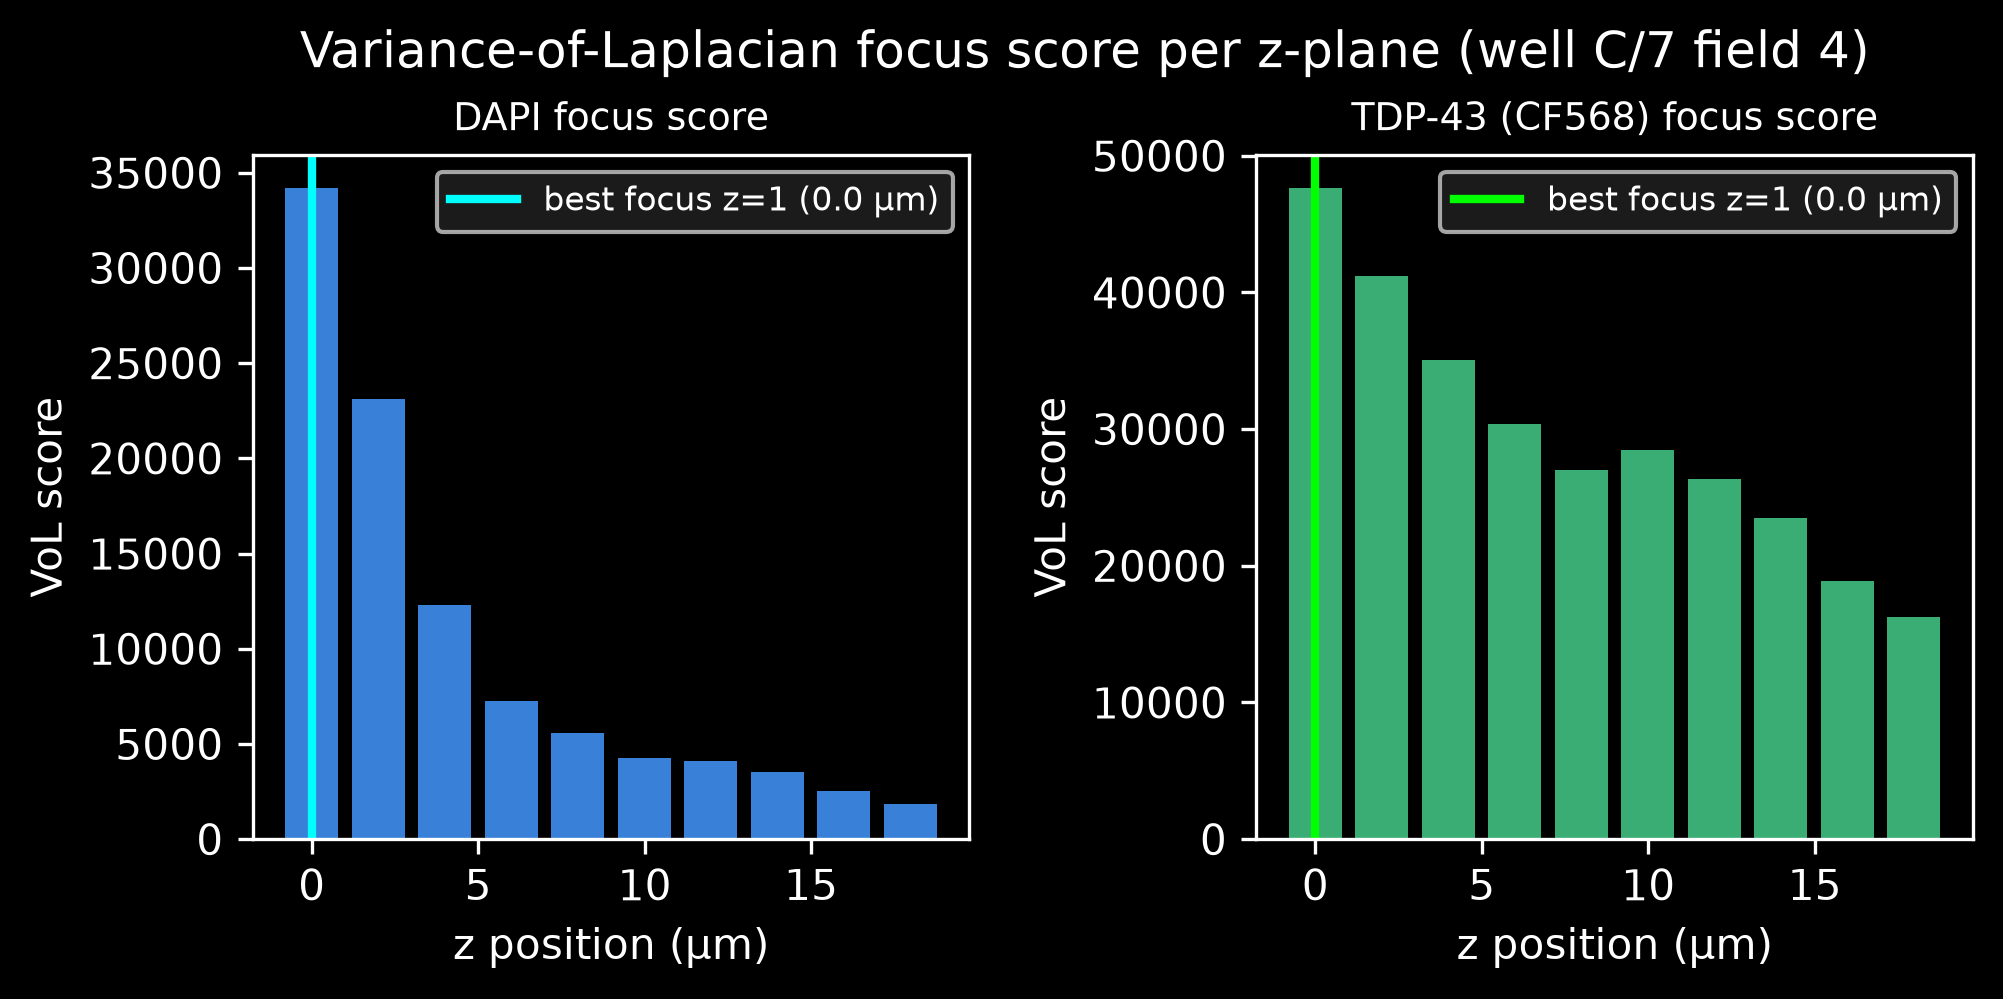

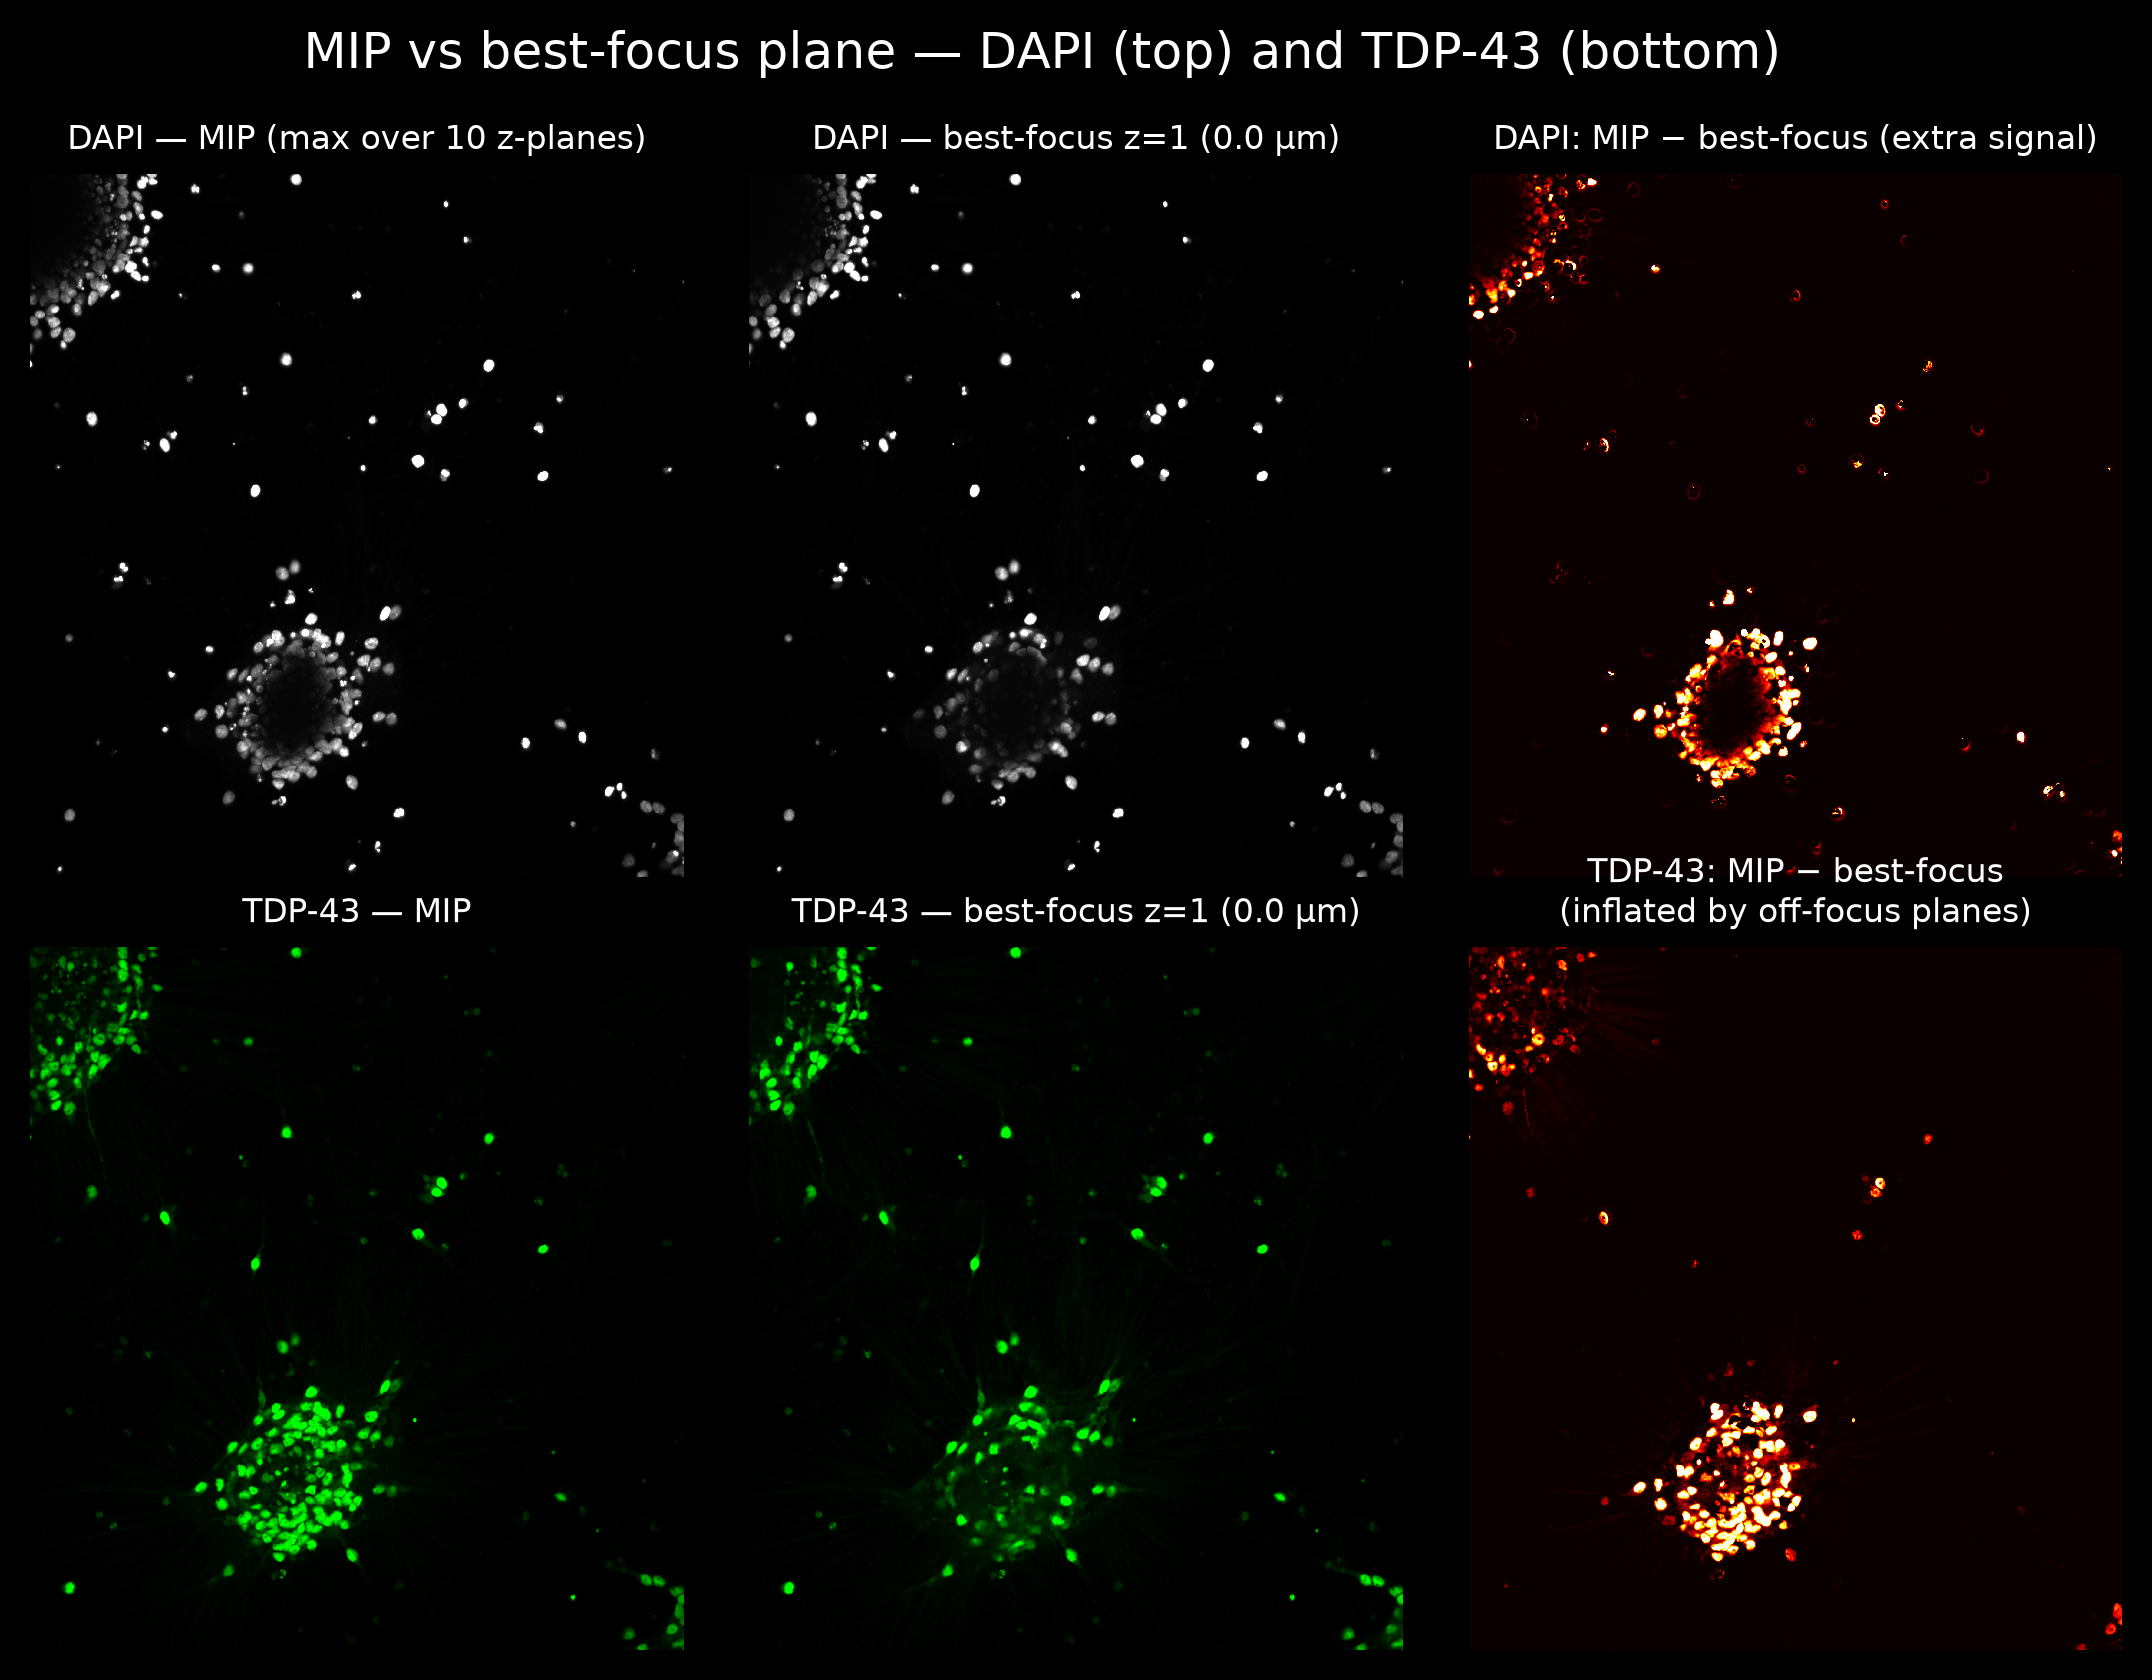

DAPI best-focus: plane 1 of 10  (z=0.0 µm)
TDP-43 best-focus: plane 1 of 10  (z=0.0 µm)
→ TDP-43 quantification uses the best-focus plane, NOT MIP, to avoid intensity inflation.


In [5]:
# Load DAPI z-stack and TDP-43 z-stack for center field of well C/7
field_arr = well['4']['0']  # (1, 4, 10, 2160, 2160)

dapi_stack = field_arr[0, 0, :, :, :].astype(np.float32)   # (10, 2160, 2160)
tdp_stack  = field_arr[0, 2, :, :, :].astype(np.float32)   # (10, 2160, 2160)

# MIP
mip_dapi = dapi_stack.max(axis=0)
mip_tdp  = tdp_stack.max(axis=0)

# Best-focus: max variance-of-Laplacian
focus_dapi = np.array([np.var(laplace(p)) for p in dapi_stack])
focus_tdp  = np.array([np.var(laplace(p)) for p in tdp_stack])
bz_dapi = int(focus_dapi.argmax())
bz_tdp  = int(focus_tdp.argmax())

# ── Plot 1: Focus scores
fig, axs = plt.subplots(1, 2, figsize=(7.4, 3.0), facecolor=BG, dpi=DPI)
fig.suptitle('Variance-of-Laplacian focus score per z-plane (well C/7 field 4)', color=FG, y=1.01)
for ax in axs: ax.set_facecolor(BG); ax.tick_params(colors=FG); [s.set_color(FG) for s in ax.spines.values()]
plt.subplots_adjust(hspace=0, wspace=0.4, top=0.87)

z_arr = np.arange(10) * Z_UM
axs[0].bar(z_arr, focus_dapi, width=1.6, color='#4499ff', alpha=0.85, edgecolor='none')
axs[0].axvline(z_arr[bz_dapi], color='cyan', lw=2, label=f'best focus z={bz_dapi+1} ({z_arr[bz_dapi]:.1f} µm)')
axs[0].set_xlabel('z position (µm)', color=FG); axs[0].set_ylabel('VoL score', color=FG)
axs[0].set_title('DAPI focus score', color=FG, fontsize=9); axs[0].legend(fontsize=8, labelcolor=FG, facecolor='#222')

axs[1].bar(z_arr, focus_tdp, width=1.6, color='#44cc88', alpha=0.85, edgecolor='none')
axs[1].axvline(z_arr[bz_tdp], color='lime', lw=2, label=f'best focus z={bz_tdp+1} ({z_arr[bz_tdp]:.1f} µm)')
axs[1].set_xlabel('z position (µm)', color=FG); axs[1].set_ylabel('VoL score', color=FG)
axs[1].set_title('TDP-43 (CF568) focus score', color=FG, fontsize=9); axs[1].legend(fontsize=8, labelcolor=FG, facecolor='#222')

fig.savefig(FIGDIR / '04_focus_scores.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Plot 2: MIP vs best-focus side-by-side (DAPI and TDP-43)
fig2, axs2 = plt.subplots(2, 3, figsize=(9.0, 6.0), facecolor=BG, dpi=DPI)
fig2.suptitle('MIP vs best-focus plane — DAPI (top) and TDP-43 (bottom)', color=FG, y=1.01)
plt.subplots_adjust(hspace=0.1, wspace=0.1, top=0.93)

panels = [
    (mip_dapi,             'gray',  'DAPI — MIP (max over 10 z-planes)'),
    (dapi_stack[bz_dapi],  'gray',  f'DAPI — best-focus z={bz_dapi+1} ({z_arr[bz_dapi]:.1f} µm)'),
    (mip_dapi - dapi_stack[bz_dapi], 'hot', 'DAPI: MIP − best-focus (extra signal)'),
    (mip_tdp,              LinearSegmentedColormap.from_list('k2g', ['black','lime']),
                                    'TDP-43 — MIP'),
    (tdp_stack[bz_tdp],   LinearSegmentedColormap.from_list('k2g', ['black','lime']),
                                    f'TDP-43 — best-focus z={bz_tdp+1} ({z_arr[bz_tdp]:.1f} µm)'),
    (mip_tdp - tdp_stack[bz_tdp],  'hot', 'TDP-43: MIP − best-focus\n(inflated by off-focus planes)'),
]

for ax, (img, cmap, title) in zip(axs2.flat, panels):
    vmin, vmax = _p(img)
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
    ax.set_title(title, color=FG, fontsize=8)
    ax.set_facecolor(BG); ax.axis('off')
    for s in ax.spines.values(): s.set_color(FG)

fig2.savefig(FIGDIR / '05_mip_vs_bestfocus.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"DAPI best-focus: plane {bz_dapi+1} of 10  (z={z_arr[bz_dapi]:.1f} µm)")
print(f"TDP-43 best-focus: plane {bz_tdp+1} of 10  (z={z_arr[bz_tdp]:.1f} µm)")
print("→ TDP-43 quantification uses the best-focus plane, NOT MIP, to avoid intensity inflation.")

## Step 5 — Calibration Confirmation

Plate: WARD00034  Instrument: {'type': 'Phenix', 'software_version': 'Python NGen 5.2.2180.466', 'serial': '2400L24302'}
Pixel size: 0.2967 µm/px  |  Z-spacing: 1.997 µm/plane

  10 µm diam → 34 px → 79 µm² = 892 px²
  15 µm diam → 51 px → 177 µm² = 2007 px²
  20 µm diam → 67 px → 314 µm² = 3569 px²

MIN_AREA=400:  35 µm²  (~6.7 µm diam) ← correct floor
MIN_AREA=3500: 308 µm²  (~20 µm diam) ← was eliminating isolated iNeurons


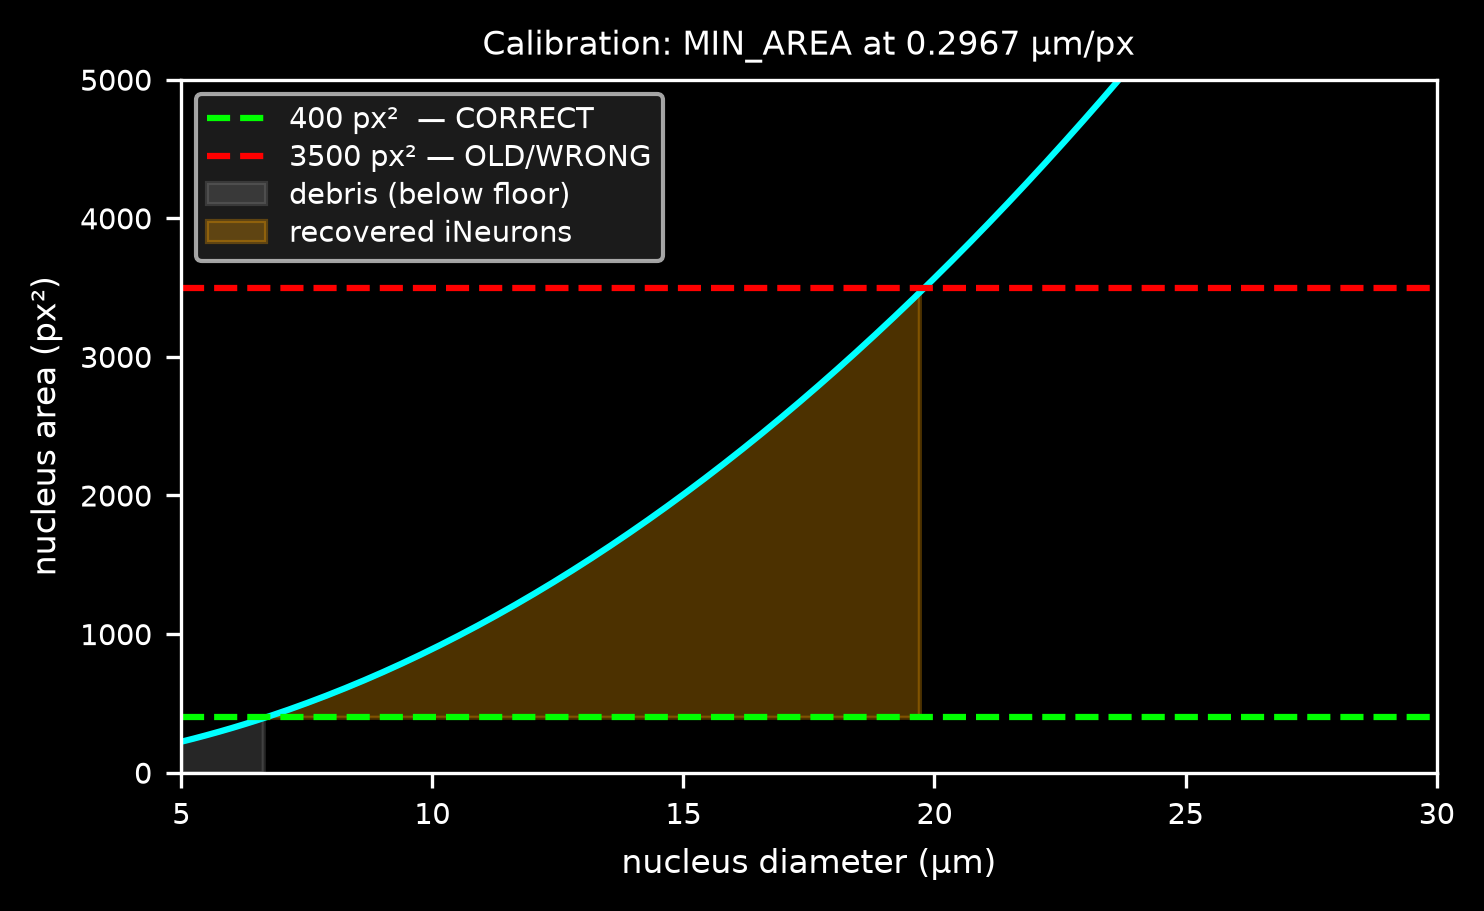

Saved: 06_calibration.png


In [6]:
# Pixel size from zarr metadata
em = attrs['experiment_metadata']
print(f"Plate: {em['plate_name']}  Instrument: {em['instrument']}")
print(f"Pixel size: {PX_UM} µm/px  |  Z-spacing: {Z_UM} µm/plane")
print()
for diam_um in [10, 15, 20]:
    area_px2 = np.pi * (diam_um / 2 / PX_UM)**2
    area_um2 = np.pi * (diam_um / 2)**2
    print(f"  {diam_um:2d} µm diam → {diam_um/PX_UM:.0f} px → {area_um2:.0f} µm² = {area_px2:.0f} px²")
print()
min_area_um2 = 400 * PX_UM**2
old_um2 = 3500 * PX_UM**2
print(f"MIN_AREA=400:  {min_area_um2:.0f} µm²  (~{2*(min_area_um2/np.pi)**0.5:.1f} µm diam) ← correct floor")
print(f"MIN_AREA=3500: {old_um2:.0f} µm²  (~{2*(old_um2/np.pi)**0.5:.0f} µm diam) ← was eliminating isolated iNeurons")

diams    = np.linspace(5, 30, 200)
areas_px2 = np.pi * (diams/2)**2 / PX_UM**2

fig, ax = plt.subplots(figsize=(5.4, 3.0), facecolor=BG, dpi=DPI)
ax.set_facecolor(BG); ax.tick_params(colors=FG, labelsize=7)
for s in ax.spines.values(): s.set_color(FG)
ax.xaxis.label.set_color(FG); ax.yaxis.label.set_color(FG)

ax.plot(diams, areas_px2, color='cyan', lw=1.5)
ax.axhline(400,  color='lime', ls='--', lw=1.5, label='400 px²  — CORRECT')
ax.axhline(3500, color='red',  ls='--', lw=1.5, label='3500 px² — OLD/WRONG')
ax.fill_between(diams, 0, areas_px2, where=areas_px2 < 400,
                color='gray', alpha=0.3, label='debris (below floor)')
ax.fill_between(diams, 400, areas_px2, where=(areas_px2 >= 400) & (areas_px2 < 3500),
                color='orange', alpha=0.3, label='recovered iNeurons')
ax.set_xlabel('nucleus diameter (µm)', fontsize=8)
ax.set_ylabel('nucleus area (px²)', fontsize=8)
ax.set_title('Calibration: MIN_AREA at 0.2967 µm/px', color=FG, fontsize=8)
ax.legend(fontsize=7, labelcolor=FG, facecolor='#222', framealpha=0.8,
          loc='upper left', borderpad=0.4, labelspacing=0.3)
ax.set_xlim(5, 30); ax.set_ylim(0, 5000)

fig.savefig(FIGDIR / '06_calibration.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: 06_calibration.png")

## Step 5b — Size Category Examples: What the MIN_AREA Fix Recovered

Re-segment the same field without any area filter, categorise every detected object into the three zones from the calibration plot, and show 3 real crops from each zone with the segmentation boundary overlaid.

Objects (no filter): 183
  <400 px²:      85  debris
  400–3499 px²:  94  recovered iNeurons
  ≥3500 px²:     4  large/clusters


/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_31413/2569667122.py:25: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
  def pick_examples(cond, n=3, sort_key=lambda r: -r.mean_intensity):


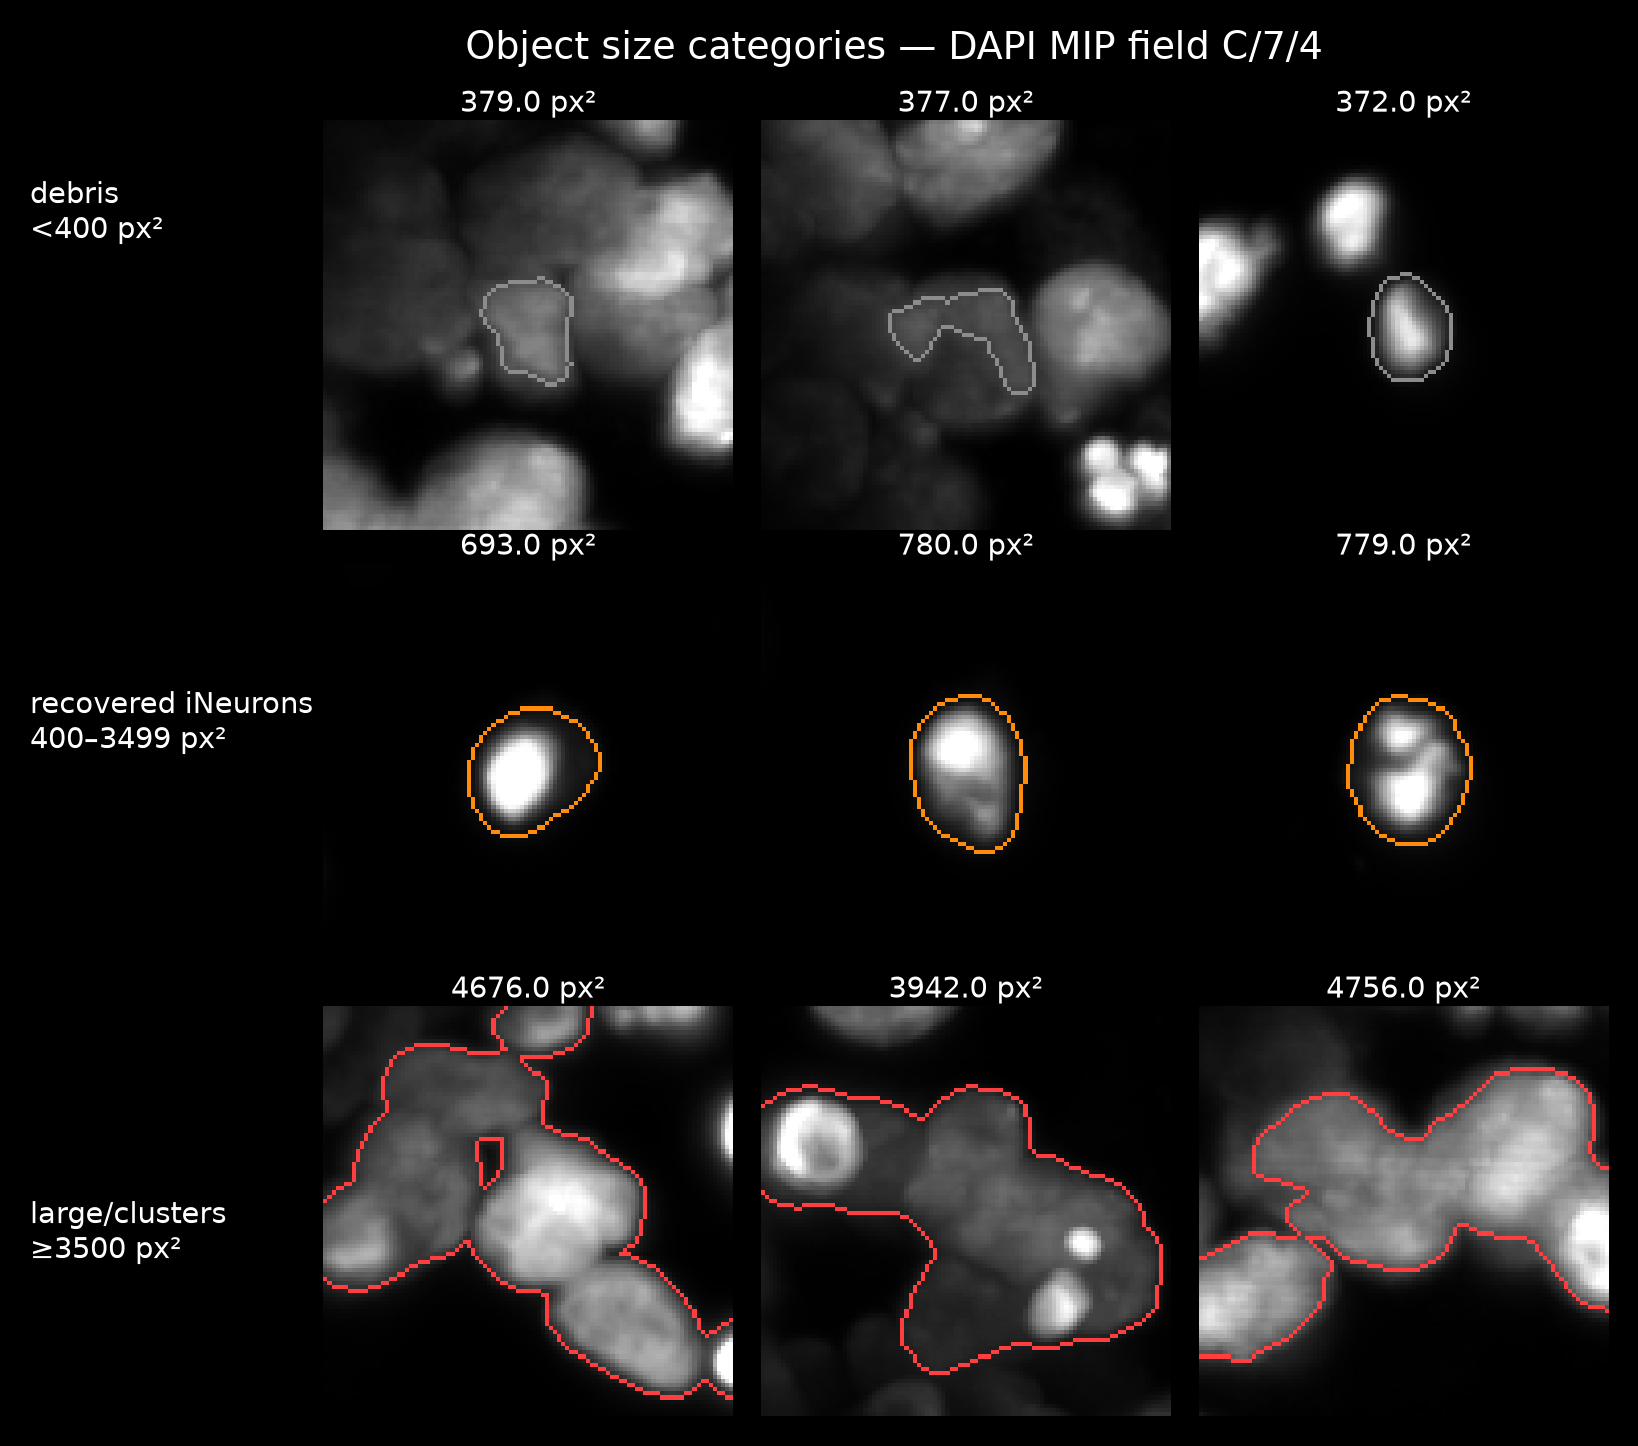

Saved: 07_size_category_examples.png


In [9]:
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import label
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries
from scipy.stats import norm as sp_norm

flat = mip_dapi.ravel()
mu, sigma = sp_norm.fit(flat)
stretched = np.clip(mip_dapi, mu - sigma, mu + 7 * sigma).astype(np.float32)
s_min, s_max = stretched.min(), stretched.max()
stretched = (stretched - s_min) / (s_max - s_min + 1e-8)
blurred = gaussian(stretched, sigma=1)
labeled_all = label(blurred > threshold_otsu(blurred))
props = regionprops(labeled_all, intensity_image=mip_dapi)
areas = np.array([r.area for r in props])

print(f"Objects (no filter): {len(props)}")
print(f"  <400 px²:      {(areas < 400).sum()}  debris")
print(f"  400–3499 px²:  {((areas >= 400) & (areas < 3500)).sum()}  recovered iNeurons")
print(f"  ≥3500 px²:     {(areas >= 3500).sum()}  large/clusters")

CROP_R = 50
H, W = mip_dapi.shape

def pick_examples(cond, n=3, sort_key=lambda r: -r.mean_intensity):
    valid = [r for r, ok in zip(props, cond)
             if ok
             and CROP_R <= r.centroid[0] <= H - CROP_R
             and CROP_R <= r.centroid[1] <= W - CROP_R]
    valid.sort(key=sort_key)
    return valid[:n]

debris    = pick_examples(areas < 400,                       sort_key=lambda r: -r.area)
recovered = pick_examples((areas >= 400) & (areas < 3500))
large     = pick_examples(areas >= 3500)

ROW_LABELS = ['debris\n<400 px²', 'recovered iNeurons\n400–3499 px²', 'large/clusters\n≥3500 px²']
ALL_EXAMPLES = [debris, recovered, large]
COLORS = [[0.55, 0.55, 0.55], [1.0, 0.55, 0.05], [1.0, 0.25, 0.25]]

fig, axs = plt.subplots(3, 3, figsize=(6.0, 6.0), facecolor=BG, dpi=DPI)
fig.suptitle('Object size categories — DAPI MIP field C/7/4', color=FG, y=0.88, fontsize=9)
plt.subplots_adjust(hspace=0.08, wspace=0.04, top=0.83, left=0.18)

# Row labels via fig.text — keeps subplot titles to one short line
for row, label_txt in enumerate(ROW_LABELS):
    y_mid = 1 - (row + 0.5) / 3
    fig.text(0.02, y_mid * 0.85 + 0.07, label_txt,
             color=FG, fontsize=7, ha='left', va='center',
             transform=fig.transFigure)

for row, (examples, rgb) in enumerate(zip(ALL_EXAMPLES, COLORS)):
    for col in range(3):
        ax = axs[row, col]
        ax.set_facecolor(BG)
        for s in ax.spines.values(): s.set_color(FG)

        if col < len(examples):
            r = examples[col]
            cy, cx = int(r.centroid[0]), int(r.centroid[1])
            crop_img = mip_dapi[cy-CROP_R:cy+CROP_R, cx-CROP_R:cx+CROP_R].astype(np.float32)
            crop_lbl = labeled_all[cy-CROP_R:cy+CROP_R, cx-CROP_R:cx+CROP_R]
            bounds   = find_boundaries((crop_lbl == r.label).astype(np.uint8), mode='outer')
            vmin, vmax = _p(crop_img)
            ax.imshow(crop_img, cmap='gray', vmin=vmin, vmax=vmax, aspect='equal', interpolation='none')
            overlay = np.zeros((*crop_img.shape, 4), dtype=np.float32)
            overlay[bounds, :3] = rgb; overlay[bounds, 3] = 1.0
            ax.imshow(overlay, aspect='equal', interpolation='none')
            ax.set_title(f'{r.area} px²', color=FG, fontsize=7, pad=2)
        else:
            ax.set_title('—', color=FG, fontsize=7, pad=2)
        ax.axis('off')

fig.savefig(FIGDIR / '07_size_category_examples.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: 07_size_category_examples.png")

In [10]:
# Verify figures
pngs = sorted(FIGDIR.glob('*.png'))
empty = [p for p in pngs if p.stat().st_size == 0]
assert pngs,  f"No figures written to {FIGDIR}"
assert not empty, f"0-byte figures: {empty}"
print(f"OK: {len(pngs)} figures in {FIGDIR.name}/")
for p in pngs:
    print(f"  {p.name}  ({p.stat().st_size//1024} KB)")

OK: 7 figures in phase_A/
  01_raw_channels.png  (791 KB)
  02_per_field_mean_intensity.png  (147 KB)
  03_vignetting_corner_center.png  (283 KB)
  04_focus_scores.png  (102 KB)
  05_mip_vs_bestfocus.png  (1037 KB)
  06_calibration.png  (76 KB)
  07_size_category_examples.png  (146 KB)
